## Silhouette Score & Cluster Evaluation

# Understanding Why WCSS Alone Is Not Enough

K-Means uses WCSS (Within Cluster Sum of Squares) to measure how close data points are to their assigned centroid.

Lower WCSS means:
- tighter clusters
- smaller internal distances
- more compact grouping

However, WCSS has an important limitation:

As the number of clusters (K) increases, WCSS always decreases.

This means:
even unrealistic clustering with too many clusters may appear “better” mathematically.

WCSS only measures:
✅ compactness

But it does NOT measure:
❌ separation between clusters

This creates an important business problem:

Clusters may become compact but still overlap heavily, making segmentation unreliable.

This is where Silhouette Score becomes important.

Silhouette Score evaluates:
- how close points are to their own cluster
- and how far they are from neighboring clusters

So instead of only asking:
“Are clusters compact?”

We now ask:
“Are clusters both compact AND well separated?”

# Understanding WCSS Intuitively

WCSS (Within Cluster Sum of Squares) measures:

> how far data points are from their assigned cluster centroid.

K-Means tries to minimize this value.

---

# Intuition

Imagine a delivery company creating delivery hubs.

If customers are located very far from their assigned hub:
- fuel cost increases
- delivery time increases
- operations become inefficient

K-Means behaves similarly.

Each centroid acts like a “center” for nearby points.

The algorithm tries to reduce the total distance between:
- points
- and their assigned centroid.

---

# Why Squaring Is Important

Distances are squared so that:
- far-away points get penalized heavily
- poorly assigned points contribute larger error

This helps K-Means strongly prefer compact clusters.

---

# Important Insight

Lower WCSS means:
- points are closer to centroids
- clusters are tighter
- internal cluster compactness improves

However:

WCSS only measures compactness.

It does NOT measure:
- separation between clusters
- overlap quality
- whether clustering is meaningful

This is why cluster evaluation metrics like Silhouette Score are important.

# Clean vs Overlapping Clusters — Intuition

## Dataset A: Clean Separated Clusters

Characteristics:
- points stay tightly grouped
- clusters are compact
- distance within clusters is small
- separation between clusters is high

This usually produces:
✅ high silhouette score

---

## Dataset B: Overlapping Clusters

Characteristics:
- boundaries become unclear
- points spread across regions
- some points become close to multiple clusters
- internal cluster compactness decreases

This usually produces:
❌ lower silhouette score

---

# Key Insight

Good clustering is not just about forming groups.

It is about:
- creating compact clusters
- while also maintaining strong separation between clusters.

Silhouette Score evaluates both simultaneously.

## Small Revision Markdown

# WCSS — Core Intuition

K-Means tries to reduce the total internal distance between:
- data points
- and their assigned centroid.

This can be understood as:
- travel cost
- grouping error
- internal clustering mistake

Lower WCSS means:
- tighter clusters
- points closer to cluster centers
- improved compactness

However:

Very low WCSS alone does NOT guarantee meaningful clustering.

If K becomes extremely large:
- clusters become artificially small
- WCSS keeps decreasing
- but business usefulness may disappear

This is why clustering evaluation requires more than just WCSS.

# Why K-Means Naturally Prefers Circular Clusters

K-Means assigns points based on:
- nearest centroid
- distance minimization

The algorithm tries to reduce:
- internal cluster distance
- total clustering error (WCSS)

When distance from a center is measured uniformly in all directions,
the natural shape that forms is:
- a circle (2D)
- or sphere (higher dimensions)

This is why K-Means works best when:
- clusters are compact
- evenly distributed
- and roughly spherical.

---

# Important Insight

K-Means does NOT explicitly create circles.

Instead:
its distance-minimization behavior naturally favors circular/spherical grouping patterns.

---

# Limitation

If real-world data forms:
- irregular shapes
- stretched patterns
- curved clusters
- density-based structures

K-Means may struggle because such patterns violate its compact centroid assumption.

# Silhouette Score — Intuition

Silhouette Score evaluates:
- how well a data point fits inside its assigned cluster
- compared to neighboring clusters.

It balances two important ideas:

## 1. Cohesion
How close a point is to its own cluster.

## 2. Separation
How far a point is from other clusters.

---

# Core Intuition

Silhouette Score asks:

> “Does this point truly belong to its assigned cluster?”

A strong cluster should have:
- high internal similarity
- strong separation from neighboring clusters.

---

# Interpretation

| Score | Meaning |
|---|---|
| Close to +1 | Strong clustering |
| Around 0 | Overlapping clusters |
| Negative | Likely wrong assignment |

---

# Important Insight

Unlike WCSS,
Silhouette Score evaluates:
- compactness
AND
- separation.

This makes it more useful for evaluating clustering quality.

# Clean vs Overlapping Clusters — Silhouette Intuition

## Clean Separated Clusters

Characteristics:
- points stay tightly grouped
- internal cluster distance is small
- neighboring clusters remain far away

Result:
✅ high silhouette score

Because:
- points strongly belong to their own cluster
- and remain clearly separated from other clusters.

---

## Messy Overlapping Clusters

Characteristics:
- cluster boundaries overlap
- points become close to neighboring clusters
- internal compactness weakens

Result:
❌ lower silhouette score

Because:
- separation decreases
- cluster assignments become less confident.

---

# Core Learning

Silhouette Score rewards:
- compact clusters
- clear separation
- confident assignments

It penalizes:
- overlap
- ambiguity
- weak cluster boundaries.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Libraries Used

We imported:

- `make_blobs` → to create synthetic clustering datasets
- `KMeans` → for clustering
- `silhouette_score` → for cluster evaluation
- `matplotlib` → for visualization

The goal is to compare:
- clean clusters
- and overlapping clusters

using both:
- visual understanding
- and numerical evaluation.

In [17]:
X_clean, _ = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.6,
    random_state=42
)

# Creating Clean Clusters

We generated a synthetic dataset with:
- 500 points
- 3 cluster centers
- low spread (`cluster_std = 0.6`)

Lower spread creates:
- tighter grouping
- clearer separation
- less overlap

This simulates an ideal clustering scenario where:
customer groups are naturally distinguishable.

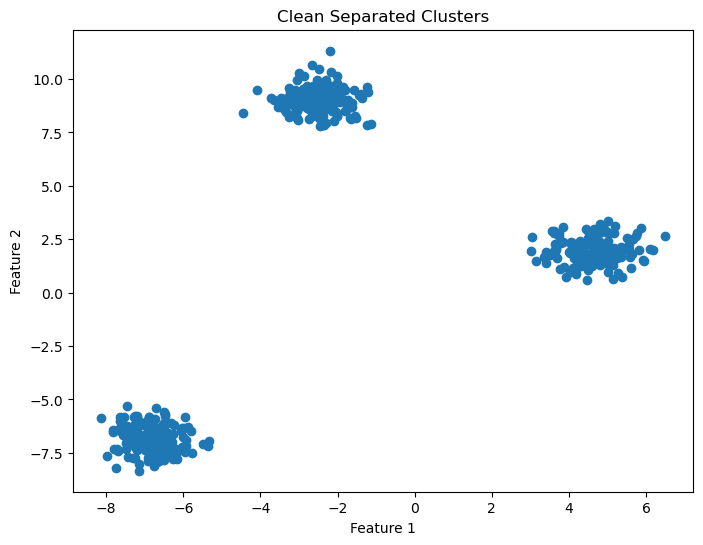

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(X_clean[:,0], X_clean[:,1])

plt.title("Clean Separated Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [19]:
#Applying K-Means

kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_clean)

C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# Note About K-Means Warning

While running K-Means on Windows systems,
a warning related to memory leak or thread allocation may appear.

This is NOT an execution failure.

The clustering still works correctly.

The warning is related to:
- internal parallel processing
- CPU thread handling
- sklearn behavior on certain Windows environments.

This is a useful real-world learning:

In practical ML workflows,
it is important to distinguish between:
- warnings
- and actual errors.

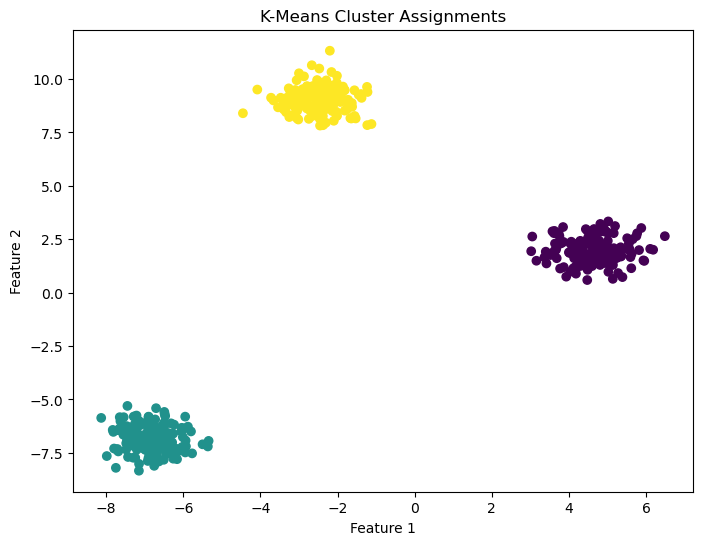

In [20]:
#Visualizing Cluster Assignments
plt.figure(figsize=(8,6))

plt.scatter(
    X_clean[:,0],
    X_clean[:,1],
    c=labels,
    cmap='viridis'
)

plt.title("K-Means Cluster Assignments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Observations From Clean Cluster Visualization

## 1. Clusters Appear Naturally Separated

The data forms:
- compact groups
- with visible spacing between clusters.

This suggests:
- low overlap
- strong separability
- clearer cluster identity.

---

## 2. K-Means Fits This Dataset Well

K-Means prefers:
- compact clusters
- roughly spherical shapes
- low overlap

The dataset aligns closely with these assumptions.

This means:
the algorithm does not struggle significantly during clustering.

---

## 3. Expected Silhouette Score

Since:
- points remain close to their own cluster
- and far from neighboring clusters

the silhouette score is expected to be:
✅ relatively high.

---

# Important Learning

Cluster evaluation is not only numerical.

Visual inspection helps identify:
- overlap
- boundary confusion
- cluster compactness
- and algorithm suitability.

## Calculating Silhouette Score

In [21]:
score_clean = silhouette_score(X_clean, labels)

print("Silhouette Score:", score_clean)

Silhouette Score: 0.9063922826528172


# Silhouette Score Result — Clean Clusters

## Obtained Score

Silhouette Score:
0.906

---

# Interpretation

This is a very high silhouette score.

It suggests:
- strong cluster compactness
- clear separation between clusters
- minimal overlap
- highly confident cluster assignments

---

# Internal Behavior

For most points:
- distance to own cluster remained small
- distance to neighboring clusters remained large

This produced strong positive silhouette values.

---

# Business Interpretation

If this represented customer segmentation:

- customer groups would be clearly distinguishable
- targeting strategies would become easier
- personalization would be more reliable
- business teams could trust the segmentation quality

---

# Important Insight

The high score does NOT only indicate:
“good clustering”

It also indicates:
the dataset structure aligns well with K-Means assumptions:
- compact groups
- low overlap
- spherical structure
- strong separability.

## Creating Overlapping Clusters

In [22]:
cluster_std = 0.6

In [23]:
X_messy, _ = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=2.2,
    random_state=42
)

In [24]:
cluster_std

0.6

# Creating Overlapping Clusters

We increased:
`cluster_std`

This caused:
- clusters to spread out more
- boundaries to weaken
- overlap to increase

Compared to the earlier clean dataset,
this setup better simulates:
- realistic customer behavior
- noisy data
- and ambiguous grouping patterns.

---

# Important Insight

Real-world data is often:
- messy
- overlapping
- and less clearly separated.



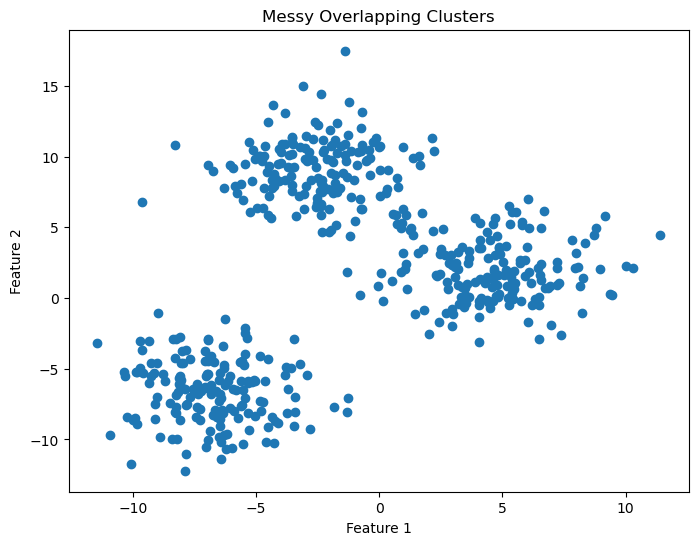

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(X_messy[:,0], X_messy[:,1])

plt.title("Messy Overlapping Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Observations From Overlapping Clusters

## 1. Clusters Became More Spread Out

Compared to the clean dataset:
- point distribution became wider
- boundaries became weaker
- visual structure became less organized

This creates a more realistic clustering scenario.

---

## 2. Overlap Became Visible

Some clusters appear close enough that:
- boundary regions start mixing
- certain points become difficult to assign confidently

This reduces clustering clarity.

---

## 3. Why K-Means Struggles More

K-Means still creates centroids.

However:
some points become similarly close to multiple centroids.

This creates:
- assignment ambiguity
- weaker separation
- lower clustering confidence

---

# Important Insight

K-Means always assigns points to the nearest centroid.

But in overlapping datasets:
the “nearest” centroid may still not represent a strong or meaningful assignment.

In [26]:
#Apply K-Means on Messy Data

kmeans_messy = KMeans(n_clusters=3, random_state=42)

labels_messy = kmeans_messy.fit_predict(X_messy)

C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


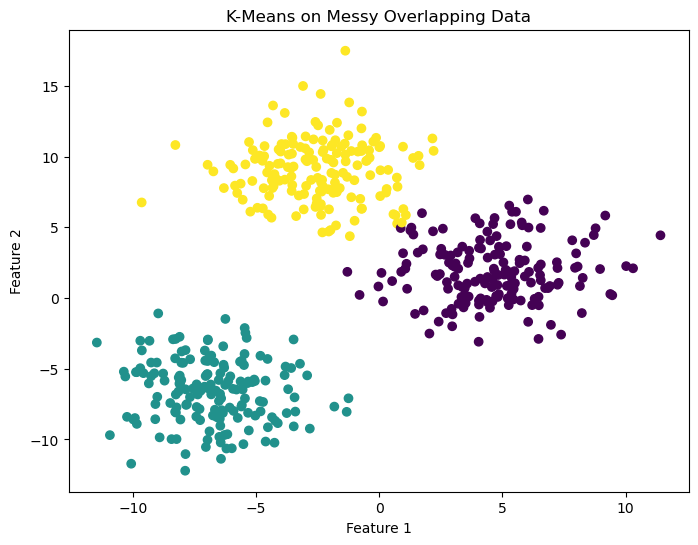

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_messy[:,0],
    X_messy[:,1],
    c=labels_messy,
    cmap='viridis'
)

plt.title("K-Means on Messy Overlapping Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Observations From Messy Cluster Assignments

Even after increasing overlap:
- three major cluster structures are still visible
- the dataset does not become completely random

However:
- some boundary regions now appear closer together
- overlap between nearby clusters increases
- assignment confidence weakens in certain areas

---

# Important Insight

Overlap does NOT automatically mean clustering failure.

Real-world datasets often contain:
- mixed behavior
- noisy boundaries
- partially overlapping groups

Good clustering analysis involves understanding:
- how much overlap exists
- and whether the segmentation remains practically useful.

---

# Analyst Perspective

Cluster evaluation should combine:
- visual interpretation
- algorithm behavior
- and numerical metrics

instead of relying on a single measure alone.

In [28]:
# Calculate Silhouette Score on Messy Data

score_messy = silhouette_score(X_messy, labels_messy)

print("Silhouette Score:", score_messy)

Silhouette Score: 0.6591953951207932


# Silhouette Score Result — Messy Overlapping Clusters

## Obtained Score

Silhouette Score:
0.659

---

# Interpretation

The score decreased compared to the clean dataset.

This indicates:
- increased overlap
- weaker cluster separation
- reduced assignment confidence

However:
the score still remains reasonably strong,
meaning the clusters are still meaningful overall.

---

# Internal Behavior

Compared to the clean dataset:
- points became more spread out
- overlap increased
- some points moved closer to neighboring clusters

This caused:
- intra-cluster distance to increase
- nearest-cluster separation to decrease

leading to a lower silhouette score.

---

# Business Interpretation

This scenario better represents real-world customer behavior.

Some customers may:
- partially belong to multiple behavioral groups
- show mixed purchasing patterns
- behave inconsistently across segments

Even with overlap,
the segmentation may still remain practically useful.

---

# Important Insight

A lower silhouette score does NOT automatically mean clustering failure.

It may simply indicate:
- realistic overlap
- noisy boundaries
- and more complex behavioral structure.

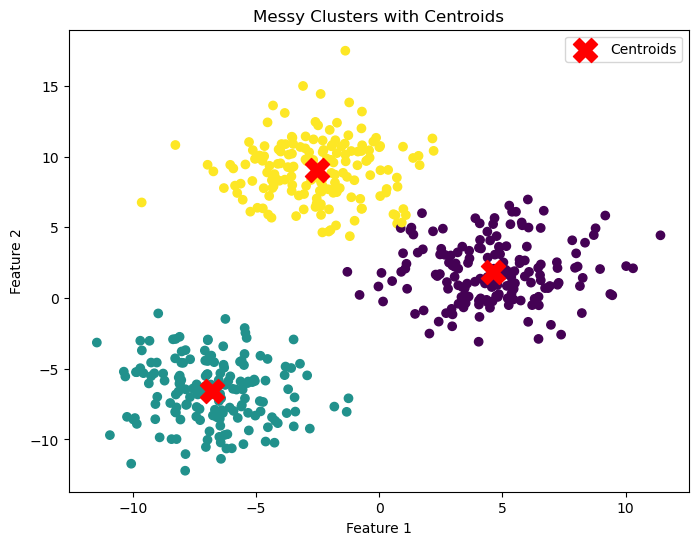

In [29]:
plt.figure(figsize=(8,6))

# Plot clustered points
plt.scatter(
    X_messy[:,0],
    X_messy[:,1],
    c=labels_messy,
    cmap='viridis'
)

# Plot centroids
plt.scatter(
    kmeans_messy.cluster_centers_[:,0],
    kmeans_messy.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Messy Clusters with Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

# Visualizing Centroids in Overlapping Clusters

The red `X` marks represent:
- cluster centroids
- the central reference points used by K-Means.

Every data point gets assigned to:
> the nearest centroid.

---

# Key Observation

In overlapping regions:
- some points appear similarly close to multiple centroids
- assignment confidence becomes weaker
- cluster boundaries become less clear

Even though K-Means still assigns every point to a cluster,
certain assignments may become ambiguous in messy datasets.

---

# Why This Matters

K-Means always performs:
> hard assignment

Meaning:
every point MUST belong to one cluster.

However, real-world behavior is often mixed.

For example:
a customer may behave partially like:
- a premium buyer
AND
- a discount-focused customer.

This creates overlap and reduces clustering confidence.

---

# Connection to Silhouette Score

Silhouette Score decreases because:
- points move farther from their own cluster
- and closer to neighboring clusters

This weakens:
- separation quality
- and assignment confidence.

---

# Important Insight

Visualizing centroids helps explain:
- how K-Means thinks internally
- why overlap creates ambiguity
- and why cluster evaluation metrics become important.

# Why Not Use One Large Central Hub?

An interesting practical question is:

> Instead of multiple hubs, why not create one large central hub?

This may appear beneficial because:
- infrastructure cost decreases
- fewer hubs need maintenance
- operations may seem simpler.

However:

Using only one hub creates a major problem:
- customers become very far from the center
- travel distance increases significantly
- delivery efficiency decreases.

---

# Connection to K-Means

K-Means tries to reduce:
- total internal distance
- travel cost within clusters
- grouping error (WCSS)

If one centroid serves all groups:
- WCSS becomes very large
- compactness decreases
- clustering quality weakens.

---

# Important Tradeoff

Real-world clustering often balances:

| Fewer Clusters | More Clusters |
|---|---|
| Lower setup cost | Higher setup cost |
| Higher travel distance | Lower travel distance |

This demonstrates that clustering is fundamentally:
- an optimization problem
- balancing efficiency and grouping quality.

---

# Real Business Insight

Machine Learning algorithms optimize mathematical objectives.

But businesses may additionally care about:
- infrastructure cost
- scalability
- operations
- logistics
- and resource allocation.

# 🚀 But What Happens When K-Means Completely Fails?

So far, K-Means worked reasonably well because:
- clusters were still somewhat separable
- centroid-based grouping still made sense
- and the data structure was relatively compact.

But real-world data is often much messier.

This raises some very important questions:

---

# 🤔 What If...

- clusters are NOT circular?
- customer behavior forms irregular shapes?
- some points are just noise or anomalies?
- overlap becomes extreme?
- cluster density varies heavily?
- centroids stop making practical sense?
- forcing every point into a cluster becomes a bad idea?

---

# 🧠 A Bigger Question

Does every data point really belong to a cluster?

Or should some points simply be treated as:
- noise
- anomalies
- outliers
- or unusual behavior?

K-Means cannot answer this.

Because K-Means always forces:
> every point into a cluster.

Even when the assignment is weak or unnatural.

---

# 🔥 This Leads to a Completely Different Clustering Philosophy

Instead of asking:

> “Which centroid is closest?”

What if we ask:

> “Which regions are densely populated?”

This single shift changes clustering completely.

---

# 📓 Next Notebook

# DBSCAN — Density-Based Clustering

In the next notebook, we will explore:
- density-based thinking
- automatic noise detection
- irregular cluster shapes
- outlier handling
- and why K-Means struggles in certain real-world datasets.

